In [3]:
import pandas as pd
import os, gc, re
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
# sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'NanumGothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [55]:
import matplotlib.pyplot as plt
import numpy as np

def grouped_plot(col_list, plot_title, color_cols):
    tot_cols = ['Segment'] + col_list
    grouped_df = df[tot_cols].groupby('Segment').mean().round()

    display(grouped_df)

    base_color = '#C8C8C8'
    highlight_color = '#c13844'

    # 막대 위치 설정
    n_segments = grouped_df.shape[0]
    n_cols = grouped_df.shape[1]
    x = np.arange(n_segments)  # x축 위치
    width = 0.8 / n_cols       # 막대 너비

    fig, ax = plt.subplots(figsize=(10, 6))
    
    idx_list = grouped_df.index  # 예: Index(['A', 'B', 'C', 'D', 'E'], dtype='object')

    col_list = []
    for color_col in color_cols :
    # print(idx_list.get_loc('A'))
        col_list.append(idx_list.get_loc(color_col))
    # print(col_list)
        
    for i, col in enumerate(grouped_df.columns):
        y = grouped_df[col].values

        
        max_idx = np.argmax(y)
        # colors = [highlight_color if j == max_idx else base_color for j in range(n_segments)] # 각 Segment에서 가장 큰 값이면 회색, 아니면 빨간색

        # 내가 지정한 세그먼트는 빨간색 나머지는 회색
        colors = [highlight_color if j in col_list else base_color for j in range(n_segments)]
        # bar 위치는 i * width 만큼 이동
        ax.bar(x + i * width, y, width=width, label=col, color=colors)

    ax.set_xticks(x + width * (n_cols - 1) / 2)
    ax.set_xticklabels(grouped_df.index)
    ax.set_title(f'Segment별 {plot_title} 평균')
    ax.set_xlabel('Segment')
    ax.set_ylabel('평균 값')
    ax.legend(title='이용 유형')

    plt.tight_layout()
    plt.show()

In [4]:
path = 'C:/final_prj/EDA/'
print(os.listdir(path))

['hyper_pred_ver_05_result.csv', 'Segment_merge_test_ver_05.parquet', 'Segment_merge_ver_03.parquet', 'Segment_merge_ver_05.parquet']


In [5]:
df = pd.read_parquet(path + 'Segment_merge_ver_05.parquet') #'hyper_pred_ver_05_result.csv',index_col=0)
df.head()

,기준년월,ID,Segment,소지카드수_이용가능_신용,입회일자_신용,수신거부여부_TM,유효카드수_신용체크,이용가능카드수_신용체크,이용카드수_신용,이용금액_R3M_신용,...,월중평잔_일시불,평잔_일시불_3M,평잔_일시불_6M,인입일수_ARS_R6M,방문후경과월_앱_R6M,불만제기후경과월_R12M,컨택건수_이용유도_TM_R6M,컨택건수_이용유도_EM_R6M,잔액_신판ca최대한도소진율_r6m,변동률_RV일시불평잔
0,201807,TRAIN_000000,D,1,20130101,0,2,2,1,196,...,1503,1791,2440,8,6,12,3,57,0.849842,0.999998
1,201807,TRAIN_000001,E,1,20170801,0,1,1,1,13475,...,4447,3761,2677,0,6,12,2,2,0.851009,1.092698
2,201807,TRAIN_000002,C,1,20080401,0,2,2,1,23988,...,5540,6796,9118,1,0,12,2,12,0.938161,1.006124
3,201807,TRAIN_000003,D,2,20160501,0,3,3,1,3904,...,606,772,884,10,6,12,2,35,1.135424,0.999998
4,201807,TRAIN_000004,E,1,20180601,0,2,2,0,0,...,0,0,21,0,6,0,7,0,0.000000,0.999998


In [5]:
## 컬럼명 전처리
### _로 시작하는 컬럼
df.columns = [
    col[1:] if col.startswith('_') else col
    for col in df.columns
]

In [6]:
cols_list = [
'이용금액_체크_R12M',
'이용금액_일시불_R12M',
'연속유실적개월수_기본_24M_카드',
'입회일자_신용',
'최종이용일자_CA',
'정상청구원금_B5M',
'평잔_일시불_6M',
'최대이용금액_일시불_R12M',
'이용금액_오프라인_B0M',
'이용건수_신용_R12M',
'최종이용일자_할부',
'이용건수_일시불_R12M',
'카드이용한도금액_B2M',
'CA이자율_할인전',
'이용건수_일시불_R6M',
'카드이용한도금액',
'이용금액_일시불_R6M',
'이용건수_신판_R12M',
'이용금액_오프라인_R3M',
'연체입금원금_B5M'
]

In [7]:
len(cols_list)

20

,이용금액_체크_R12M
Segment,
A,4047.0
B,10618.0
C,14590.0
D,13322.0
E,4220.0


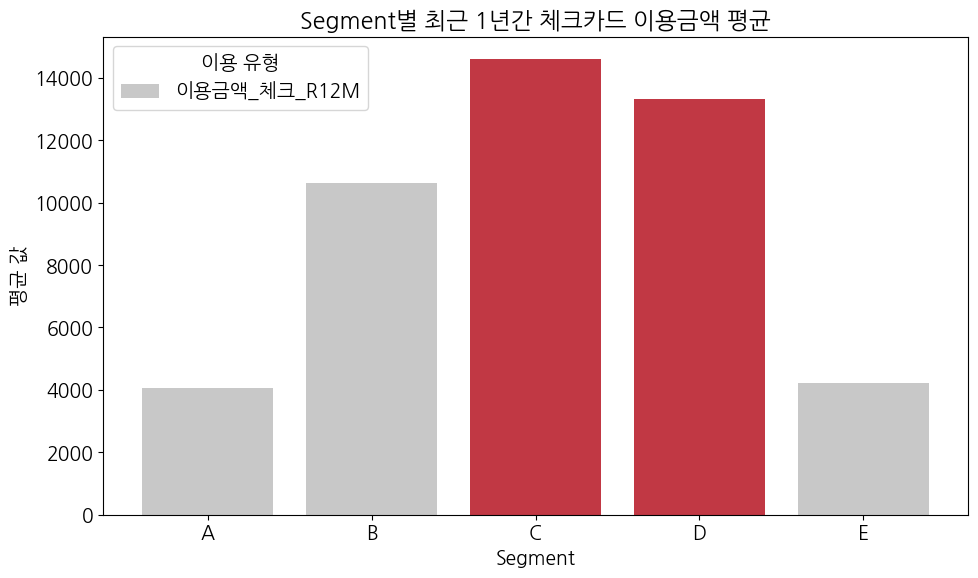

In [61]:
grouped_plot(['이용금액_체크_R12M'], '최근 1년간 체크카드 이용금액',['C','D'])

,이용금액_일시불_R12M
Segment,
A,383016.0
B,323991.0
C,176200.0
D,98274.0
E,26354.0


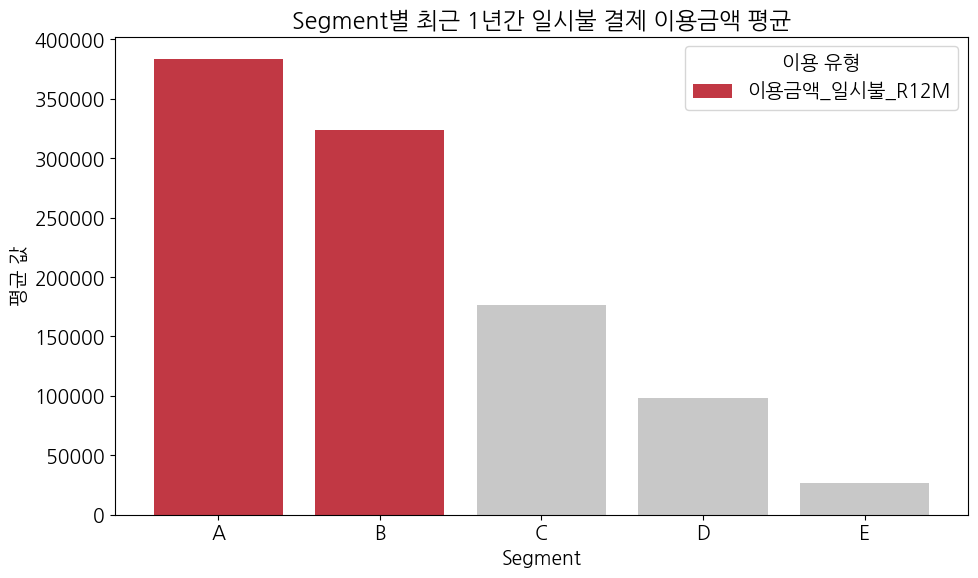

In [62]:
grouped_plot(['이용금액_일시불_R12M'],'최근 1년간 일시불 결제 이용금액',['A','B'])

,연속유실적개월수_기본_24M_카드
Segment,
A,23.0
B,23.0
C,21.0
D,19.0
E,11.0


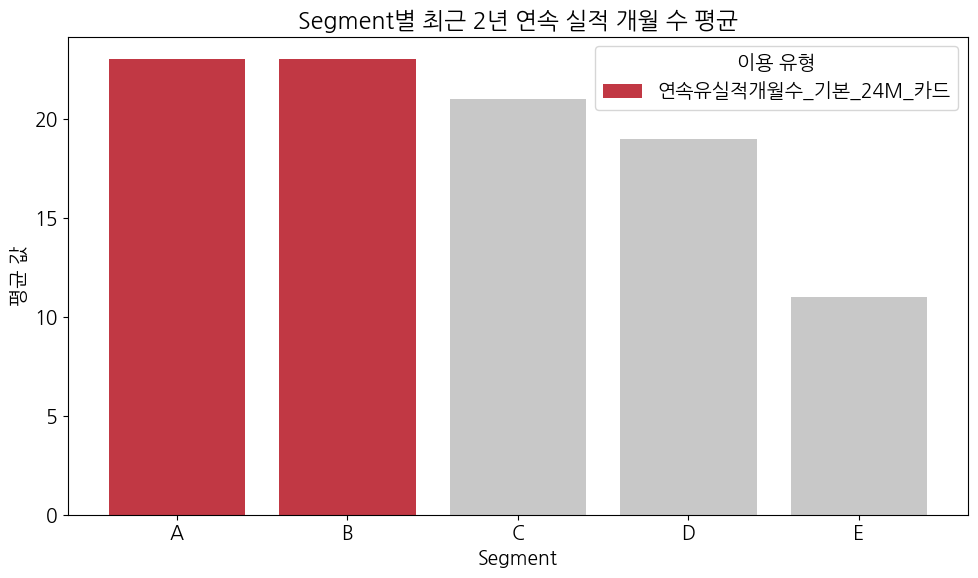

In [66]:
grouped_plot(['연속유실적개월수_기본_24M_카드'], '최근 2년 연속 실적 개월 수',['A','B'])

In [ ]:
'입회일자_신용',
'최종이용일자_CA',

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 예시용 DataFrame (원래는 MultiIndex 상태라고 가정)
df1 = df[['Segment', '입회일자_신용','최종이용일자_CA' ]]# MultiIndex → 일반 컬럼으로 변환

## drop 10101
df1= df1[(df1['최종이용일자_CA'] != '10101')& (df1['입회일자_신용'] != '10101')]
# 날짜 컬럼 처리 (가능하면 변환)
df1['최종이용일자_CA'] = pd.to_datetime(df['최종이용일자_CA'], errors='coerce', format='%Y%m%d')
df1['입회일자_신용'] = pd.to_datetime(df['입회일자_신용'], errors='coerce', format='%Y%m%d')
# 날짜 오름차순 정렬


In [76]:
df1.head()

,Segment,입회일자_신용,최종이용일자_CA
100836,A,2010-05-27,2010-05-27
500836,A,2010-05-27,2010-05-27
900836,A,2010-05-27,2010-05-27
1300836,A,2010-05-27,2010-05-27
1700836,A,2010-05-27,2010-05-27


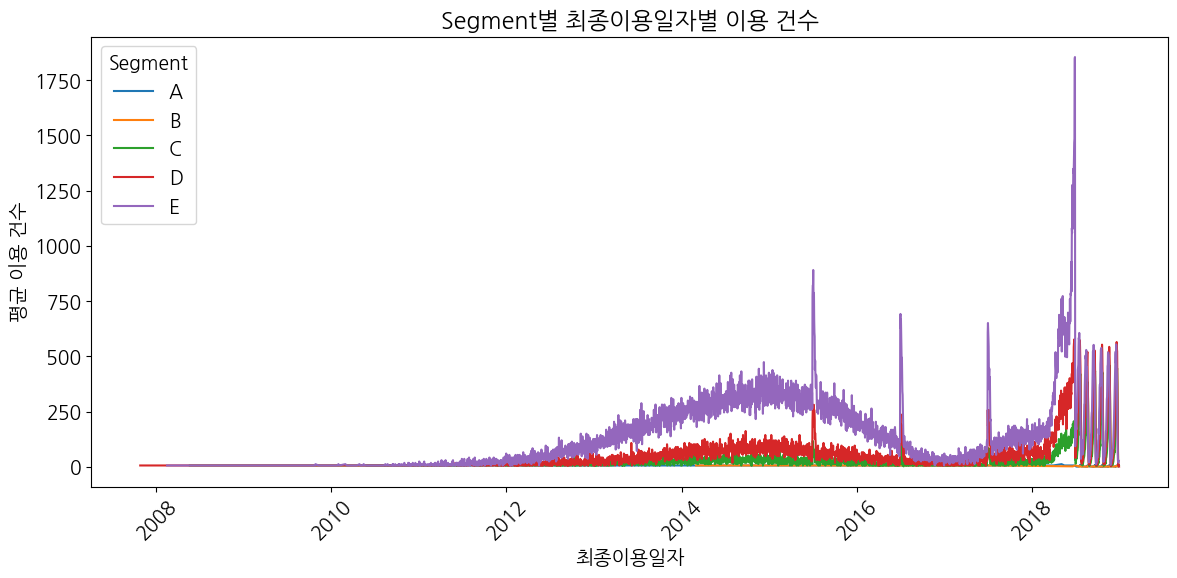

In [83]:
# 1. 날짜별로 Segment별 count 집계
df2 =df1[df1['최종이용일자_CA'] != '10101']
df2['최종이용일자_CA'] = pd.to_datetime(df1['최종이용일자_CA'], errors='coerce', format='%Y%m%d')
df_plot = df2.groupby(['Segment', '최종이용일자_CA']).size().reset_index(name='count')

# 2. 시계열 그래프 (Segment별 선 그래프)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='최종이용일자_CA', y='count', hue='Segment') #, marker='o')

plt.title('Segment별 최종이용일자별 이용 건수')
plt.xlabel('최종이용일자')
plt.ylabel('평균 이용 건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

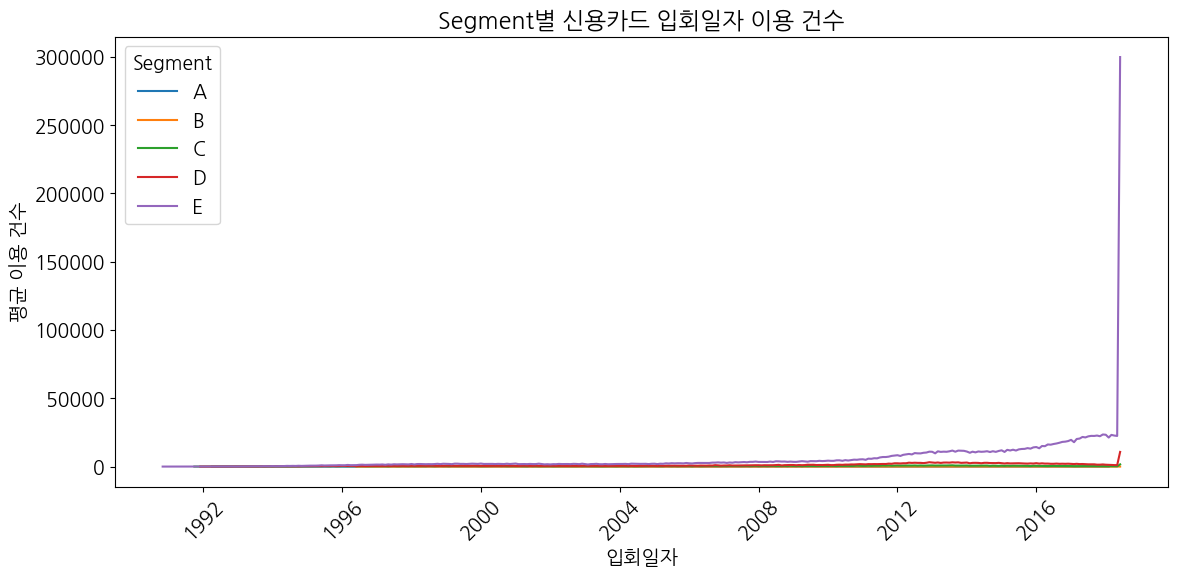

In [84]:
# 1. 날짜별로 Segment별 count 집계
df3 =df1[df1['입회일자_신용'] != '10101']
df3['입회일자_신용'] = pd.to_datetime(df1['입회일자_신용'], errors='coerce', format='%Y%m%d')
df_plot = df3.groupby(['Segment', '입회일자_신용']).size().reset_index(name='count')

# 2. 시계열 그래프 (Segment별 선 그래프)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='입회일자_신용', y='count', hue='Segment') #, marker='o')

plt.title('Segment별 신용카드 입회일자 이용 건수')
plt.xlabel('입회일자')
plt.ylabel('평균 이용 건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df.groupby('Segment').입회일자_신용.value_counts().groupby(level=0).head(3)

Segment  입회일자_신용 
A        19951001        30
         19940901        18
         19951101        18
B        20000701        12
         20080801        12
         20180601        12
C        20180601      1620
         20130801       918
         20130101       858
D        20180601     10734
         20121201      3192
         20130801      3120
E        20180601    299772
         20171201     23496
         20180101     23304
Name: count, dtype: int64

In [9]:
df.groupby('Segment').최종이용일자_CA.value_counts().groupby(level=0).head(4)

Segment  최종이용일자_CA
A        10101            348
         20180505          12
         20181025          10
         20181022           9
B        10101             36
         20140302           6
         20140317           6
         20140614           6
C        10101          51234
         20181122         458
         20181223         446
         20180922         434
D        10101         174161
         20180628         578
         20180720         574
         20181221         565
E        10101        1408734
         20180630        1855
         20180629        1848
         20180628        1485
Name: count, dtype: int64

### 이용 금액 일시불
- 누적값
- A > B > C > D > E
  - A/B는 평균 이용금액 차이가 별로 안남
  - CDE는 약 2배 가까이 차이

In [53]:
이용금액_일시불 = [col for col in cols_list if re.search(r'(이용금액).*(일시불).*', col)]
이용금액_일시불 =sorted(이용금액_일시불, key=lambda x: int(re.search(r'(\d+)M', x).group(1)))
이용금액_일시불

['이용금액_일시불_R6M', '이용금액_일시불_R12M', '최대이용금액_일시불_R12M']

,이용금액_일시불_R6M,이용금액_일시불_R12M,최대이용금액_일시불_R12M
Segment,,,
A,114671.0,383016.0,67453.0
B,104607.0,323991.0,47270.0
C,70802.0,176200.0,31903.0
D,45822.0,98274.0,17729.0
E,14167.0,26354.0,5683.0


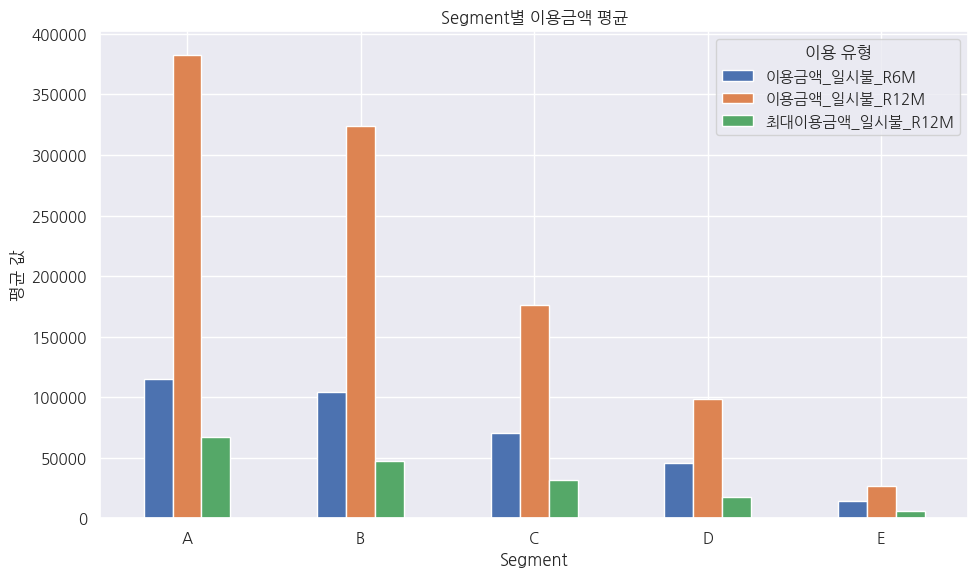

In [54]:
grouped_plot(이용금액, '이용금액')

#### 최대이용금액_일시불_R12M, 카드이용한도금액
- A > B > C > D > E
- 각 계급별 평균 최대 일시불 이용 금액 차이가 크다 

,최대이용금액_일시불_R12M,카드이용한도금액
Segment,,
A,67453.0,197599.0
B,47270.0,126400.0
C,31903.0,98017.0
D,17729.0,69322.0
E,5683.0,45248.0


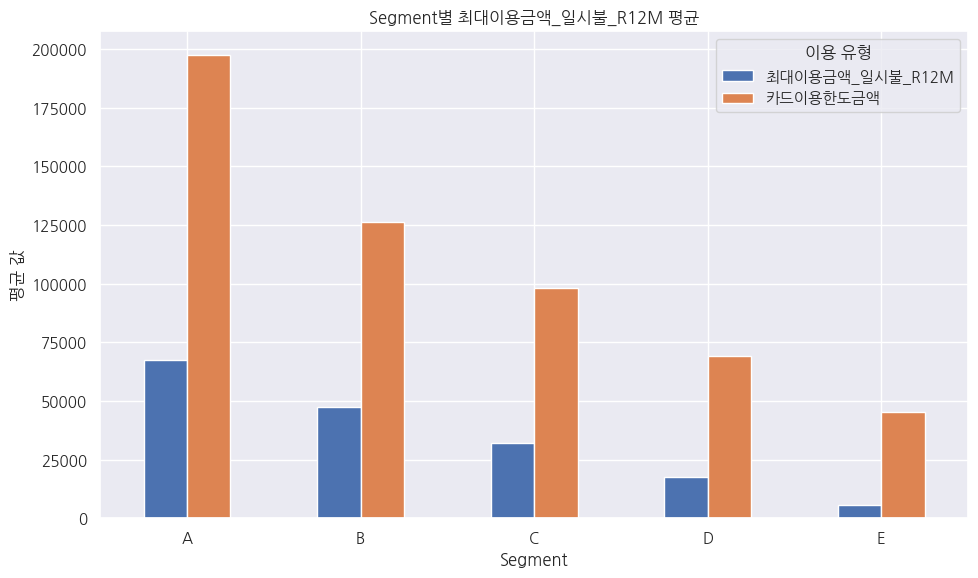

In [57]:
grouped_plot(['최대이용금액_일시불_R12M','카드이용한도금액'], '최대이용금액_일시불_R12M')

#### 연속유실적개월수_기본_24M_카드
- A =B > C > D > E
- E 등급 실적 유지 개월수가 작음
  - E -> D 등급으로 승급하기 위해서는 실적 유지 개월수를 늘려야 함
  - 마케팅 제안....

,연속유실적개월수_기본_24M_카드
Segment,
A,23.0
B,23.0
C,21.0
D,19.0
E,11.0


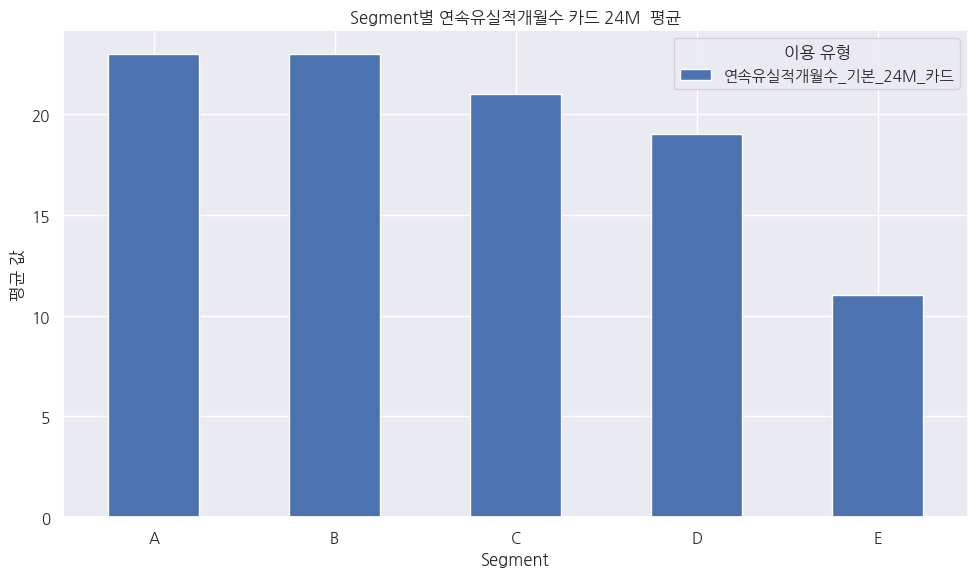

In [59]:
grouped_plot(['연속유실적개월수_기본_24M_카드'], '연속유실적개월수 카드 24M ')

#### '입회일자_신용'
- 신용카드 발급일
- A
  - 19951001
- B
  - 20000701
- C/D/E
    - 20180601에 발급받은 사람들이 다수 

In [69]:
df.groupby('Segment').입회일자_신용.value_counts().groupby(level=0).head(5)

Segment  입회일자_신용 
A        19951001        30
         19940901        18
         19951101        18
         19960101        18
         19961001        18
B        20000701        12
         20080801        12
         20180601        12
         19960601         6
         19970401         6
C        20180601      1620
         20130801       918
         20130101       858
         20111001       828
         20121201       828
D        20180601     10734
         20121201      3192
         20130801      3120
         20131001      3090
         20130101      3018
E        20180601    299772
         20171201     23496
         20180101     23304
         20180301     23196
         20171001     22716
Name: count, dtype: int64

#### 최종이용일자_CA
- 10101 의미..?
- E 등급이 현금 서비스 이용을 가장 많이 한다.

In [71]:
'최종이용일자_CA'
df.groupby('Segment').최종이용일자_CA.value_counts().groupby(level=0).head(10)

Segment  최종이용일자_CA
A        10101            348
         20180505          12
         20181025          10
         20181022           9
         20180721           8
         20180921           8
         20180924           8
         20181023           8
         20180720           7
         20180822           7
B        10101             36
         20140302           6
         20140317           6
         20140614           6
         20150302           6
         20150728           6
         20170803           6
         20180630           6
         20180703           6
         20180720           4
C        10101          51234
         20181122         458
         20181223         446
         20180922         434
         20181222         431
         20181023         427
         20181022         424
         20180921         423
         20180722         421
         20181221         418
D        10101         174161
         20180628         578
         20180720    

#### '정상청구원금_B5M'
- 연체 이자나 수수료 등을 제외하고 실제로 청구되는 원금 금액
- A/B > C > D > E
- 각 그룹간 평균 청구원금액 차이가 크다

,정상청구원금_B5M
Segment,
A,46525.0
B,44321.0
C,20804.0
D,11555.0
E,3497.0


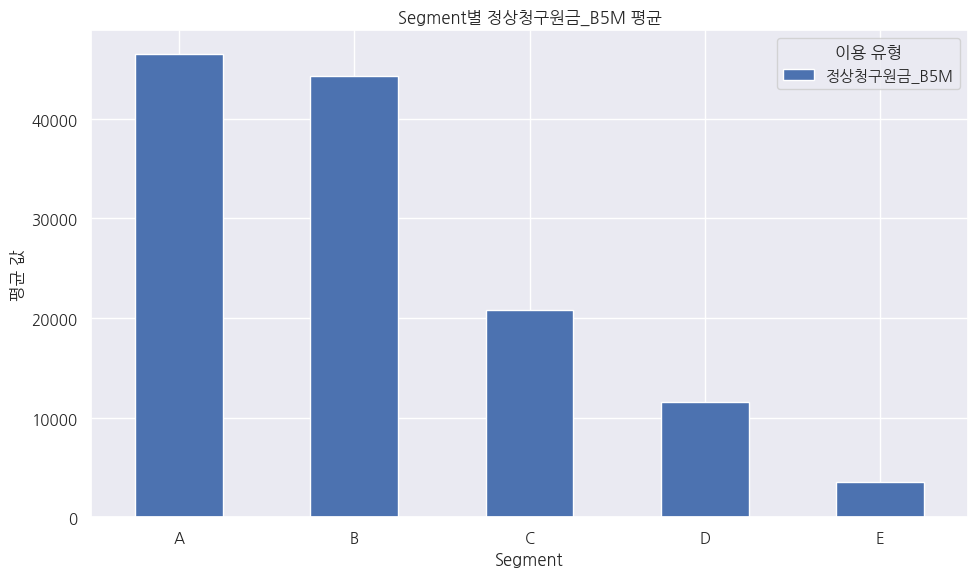

In [72]:
grouped_plot(['정상청구원금_B5M'],'정상청구원금_B5M')

#### '평잔_일시불_6M'
- 일정 금액 이상의 평균 잔액을 유지하면서 일시불 결제

#### '연체입금원금_B5M'
- 연체된 대출금의 원금
- B > C > D > A > E
- B 그룹이 고액 대출, A/C 그룹 소액 대출

,평잔_일시불_6M,연체입금원금_B5M
Segment,,
A,23138.0,2733.0
B,16163.0,8942.0
C,14118.0,5322.0
D,9046.0,3055.0
E,2640.0,1098.0


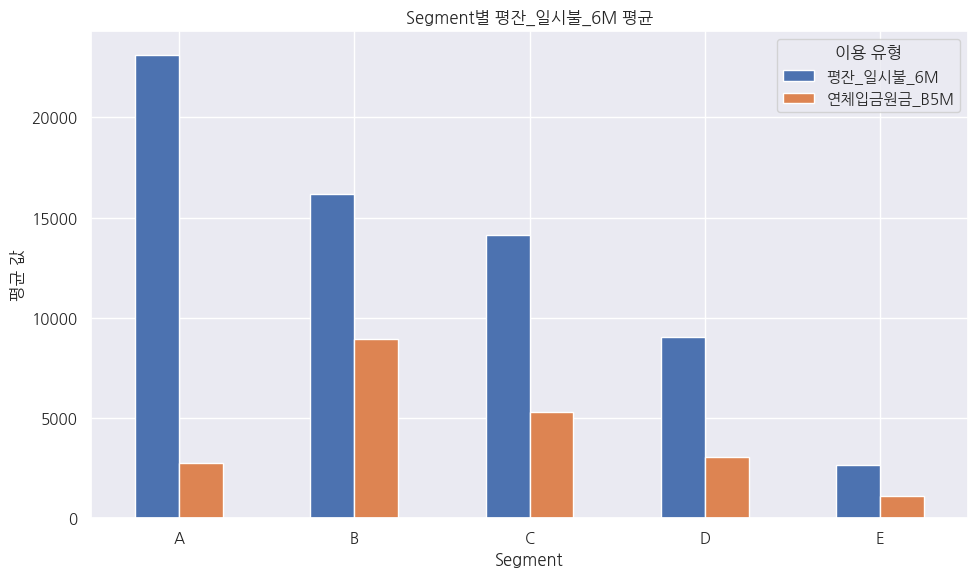

In [74]:
grouped_plot(['평잔_일시불_6M','연체입금원금_B5M'],'평잔_일시불_6M')

#### 이용금액 오프라인
- A > B > C > D > E

In [78]:
이용금액_오프 = [col for col in cols_list if re.search(r'(이용금액).*(오프라인).*', col)]
이용금액_오프

['이용금액_오프라인_B0M', '이용금액_오프라인_R3M']

,이용금액_오프라인_B0M,이용금액_오프라인_R3M
Segment,,
A,20009.0,71425.0
B,16931.0,61970.0
C,10466.0,35077.0
D,7759.0,23777.0
E,2321.0,7273.0


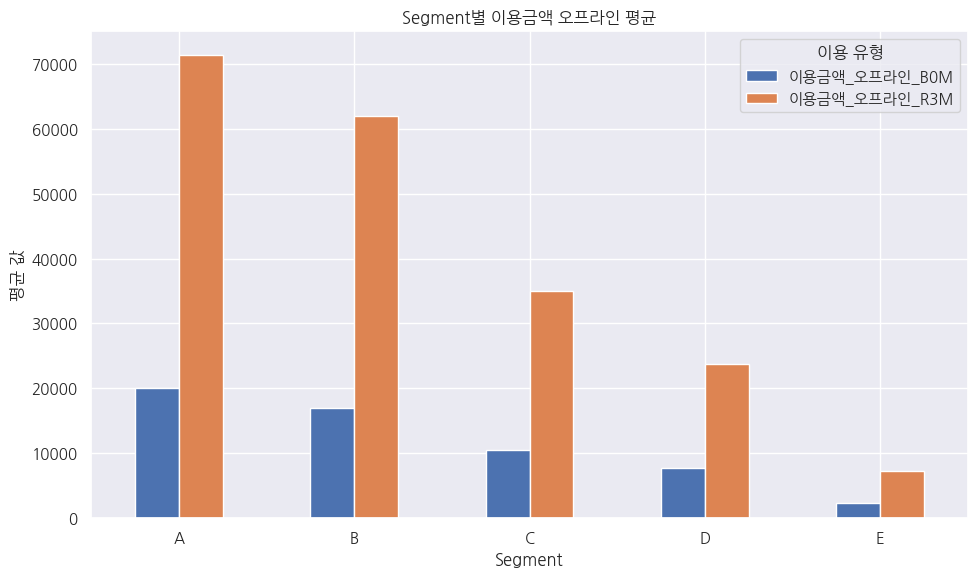

In [79]:
grouped_plot(이용금액_오프, '이용금액 오프라인')

### 이용건수
- 일시불
  - B > A > C > D > E
- 신용/신판
  - B > A > C > D > E

In [84]:
이용건수_일시불 = [col for col in cols_list if re.search(r'(이용건수).*(일시불)', col)]
이용건수_일시불 =sorted(이용건수_일시불, key=lambda x: int(re.search(r'(\d+)M', x).group(1)))
이용건수_일시불

['이용건수_일시불_R6M', '이용건수_일시불_R12M']

,이용건수_일시불_R6M,이용건수_일시불_R12M
Segment,,
A,317.0,612.0
B,326.0,626.0
C,230.0,459.0
D,179.0,360.0
E,64.0,121.0


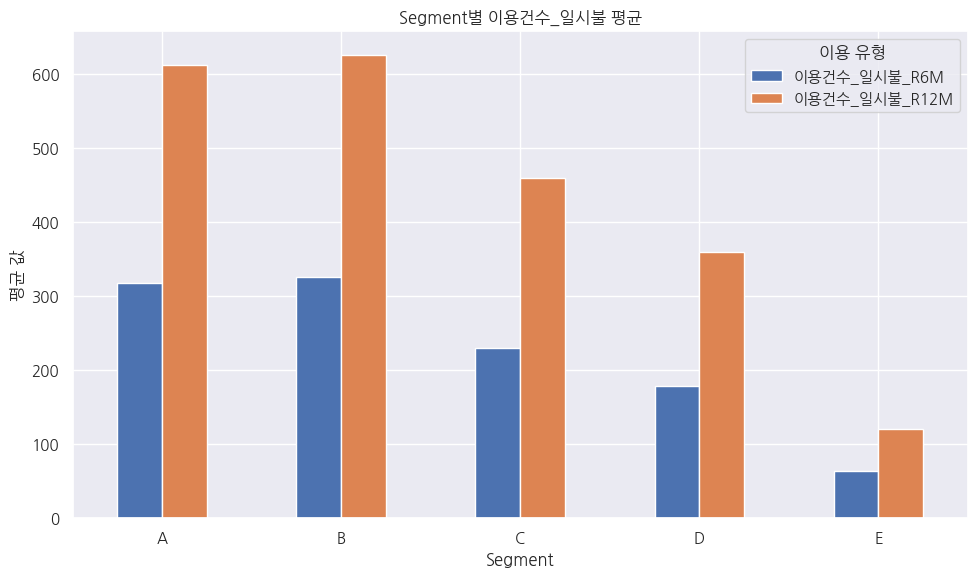

In [85]:
grouped_plot(이용건수_일시불, '이용건수_일시불')

In [91]:
이용건수_신용_신판 = [col for col in cols_list if re.search(r'^이용건수_(?!일시불).*', col)]
이용건수_신용_신판

['이용건수_신용_R12M', '이용건수_신판_R12M']

,이용건수_신용_R12M,이용건수_신판_R12M
Segment,,
A,633.0,627.0
B,661.0,652.0
C,471.0,467.0
D,369.0,367.0
E,124.0,123.0


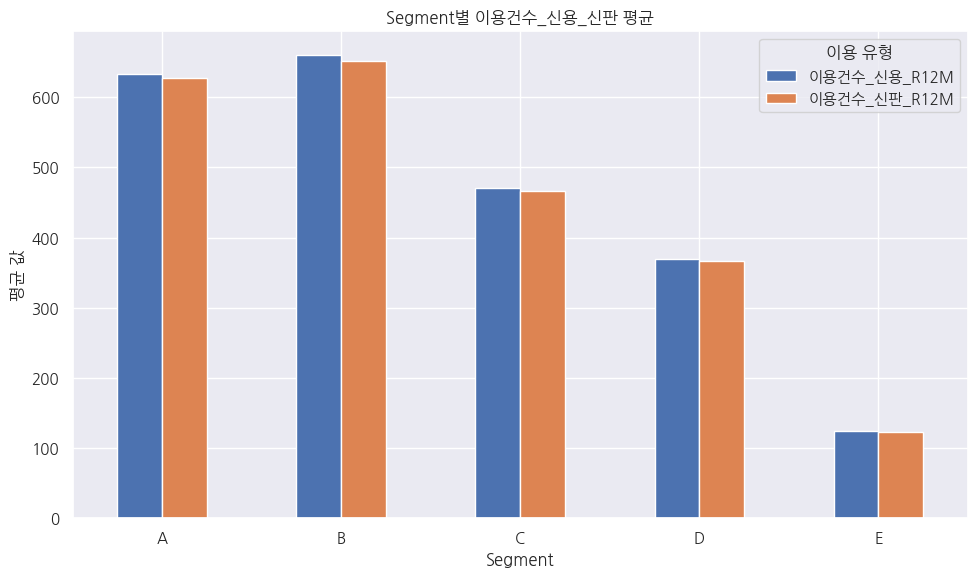

In [92]:
grouped_plot(이용건수_신용_신판, '이용건수_신용_신판')

#### 최종이용일자 할부
- C/D/E 등급은 할부 이용 빈도가 높다.
  - 최종이용일자의 상위 10개를 확인: 날짜 간격이 짧음 

In [93]:
df.groupby('Segment').최종이용일자_할부.value_counts().groupby(level=0).head(10)

Segment  최종이용일자_할부
A        10101            36
         20180617         24
         20181022         14
         20181122         14
         20180528         12
         20180726         10
         20180625          9
         20180710          9
         20180920          9
         20180924          9
B        20180924          8
         20181123          7
         20180521          6
         20180724          6
         20180822          5
         20181005          5
         20180723          4
         20181021          4
         20181023          4
         20181024          4
C        10101          9397
         20180628        666
         20180629        616
         20180627        570
         20180622        568
         20180630        561
         20180624        545
         20180625        519
         20180715        514
         20180626        505
D        10101         31315
         20180630       2080
         20180626       2039
         20180627       

#### 카드 한도 금액
- '카드이용한도금액_B2M' : 기준 시점으로부터 2개월 전
- 2개월 전이나 현재 카드 이용한도금액의 차이 없음

In [94]:
카드한도 = [col for col in cols_list if re.search(r'카드이용.*', col)]
카드한도

['카드이용한도금액_B2M', '카드이용한도금액']

,카드이용한도금액_B2M,카드이용한도금액
Segment,,
A,198553.0,197599.0
B,123228.0,126400.0
C,97410.0,98017.0
D,68960.0,69322.0
E,45533.0,45248.0


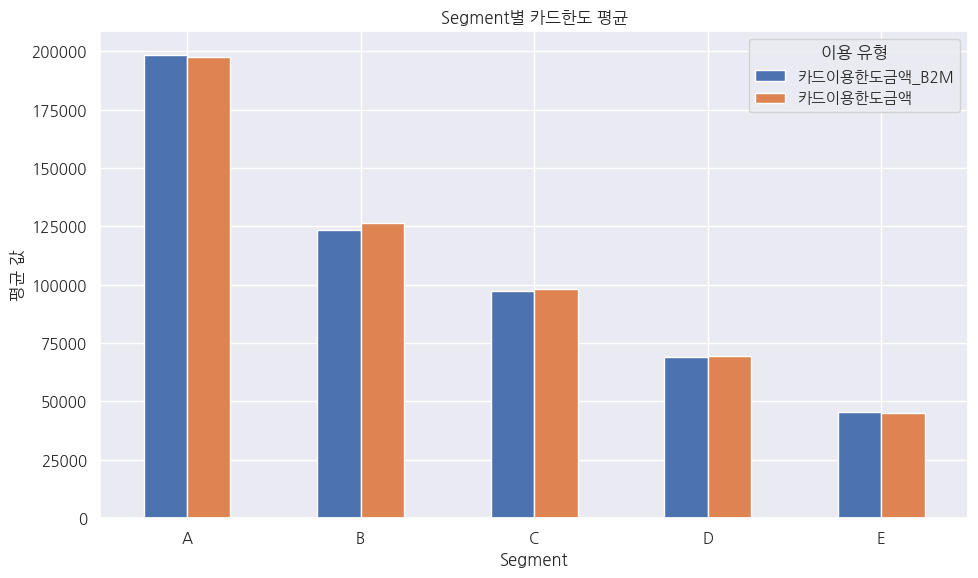

In [95]:
grouped_plot(카드한도, '카드한도')